<a href="https://colab.research.google.com/github/Hassanmufezshaikh/AI-Agents/blob/main/LoopAgentArchitecture.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

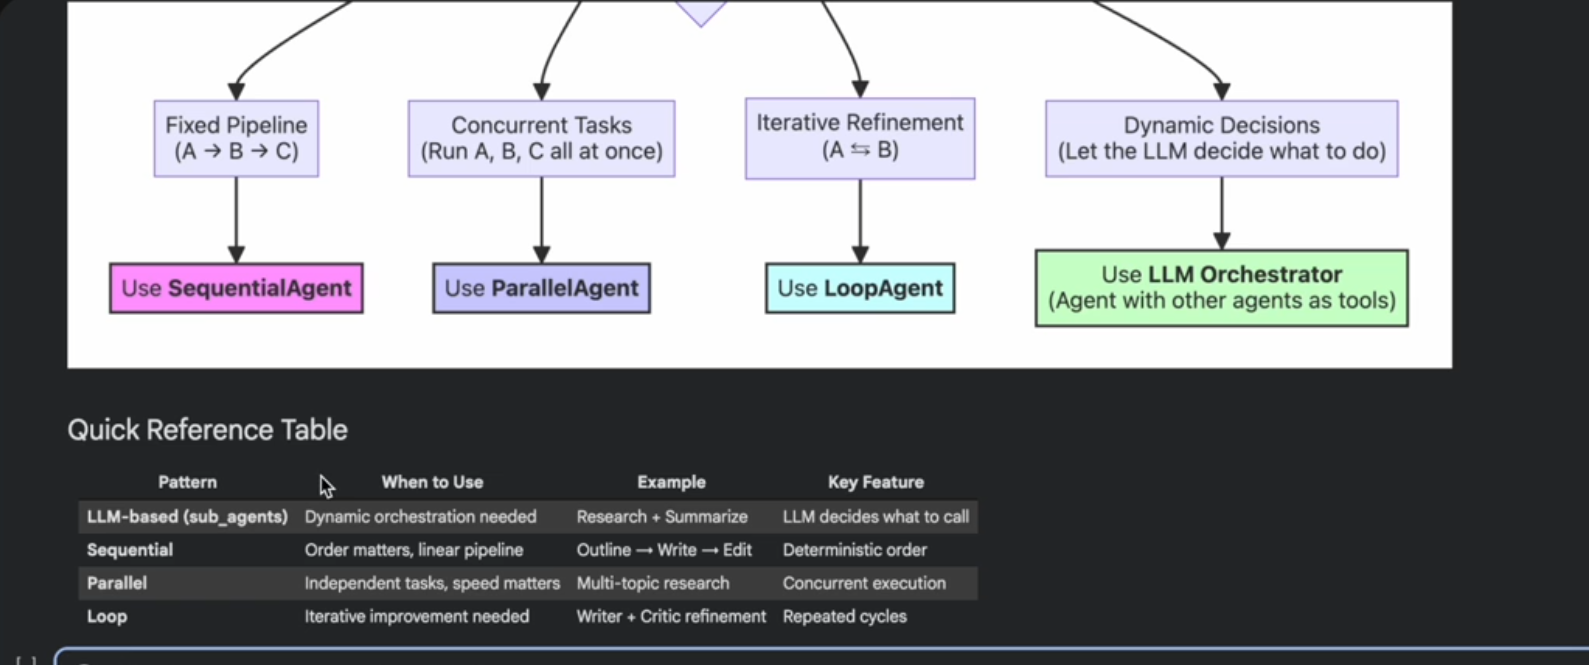

In [ ]:
from IPython.display import Image, display

image_path = '/content/Screenshot 2026-05-21 211915.png'
display(Image(filename=image_path))

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
!pip install --upgrade google-adk google-genai

  Using cached google_genai-2.5.0-py3-none-any.whl.metadata (52 kB)


In [ ]:
import google.adk
print(google.adk.__version__)

2.0.0


In [ ]:
!wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64
!chmod +x cloudflared-linux-amd64
print(" Tunnel Components imported successfully")



 Tunnel Components imported successfully


In [ ]:
import os
from google.colab import userdata
userdata.get('gemeni')

try:
  GOOGLE_API_KEY = userdata.get('gemeni')
  os.environ["GOOGLE_API_KEY"] = GOOGLE_API_KEY
  print("Gemini API Key Setup Complete")
except Exception as e :
  print("Authencation Error: Please add 'GEMENI_API_KEY' to your kaggale secrets, Details : {e}")

Gemini API Key Setup Complete


In [ ]:
from google.adk.agents import (
    Agent,
    SequentialAgent,
    ParallelAgent,
    LoopAgent
)
import google.adk.workflow as adk_workflow # Import the workflow module as an alias

from google.adk.models.google_llm import Gemini
from google.adk.runners import InMemoryRunner
from google.adk.tools import google_search, AgentTool, FunctionTool
from google.genai import types

print("ADK components imported successfully.")

ADK components imported successfully.


In [ ]:
import google.adk.tools as tools

print(dir(tools))

['APIHubToolset', 'AgentTool', 'AgentTool', 'Any', 'ApiRegistry', 'AuthToolArguments', 'BaseTool', 'DiscoveryEngineSearchTool', 'ExampleTool', 'FunctionTool', 'FunctionTool', 'LongRunningFunctionTool', 'MCPToolset', 'McpToolset', 'SearchResultMode', 'TYPE_CHECKING', 'ToolContext', 'TransferToAgentTool', 'VertexAiSearchTool', '_LAZY_MAPPING', '__all__', '__builtins__', '__cached__', '__dir__', '__doc__', '__file__', '__getattr__', '__loader__', '__name__', '__package__', '__path__', '__spec__', '_automatic_function_calling_util', '_forwarding_artifact_service', '_function_parameter_parse_util', '_function_tool_declarations', 'agent_tool', 'base_tool', 'base_toolset', 'computer_use', 'enterprise_web_search', 'exit_loop', 'function_tool', 'get_user_choice', 'google_maps_grounding', 'google_search', 'google_search', 'google_search_tool', 'importlib', 'load_artifacts', 'load_memory', 'logging', 'preload_memory', 'set_model_response_tool', 'sys', 'tool_configs', 'tool_confirmation', 'tool_co

In [ ]:
from google.genai import types

retry_config=types.HttpRetryOptions(
attempts=5, # Maximum retry attempts
exp_base=7, # Delay multiplier
initial_delay=1, # Initial delay before first retry (in seconds)
http_status_codes=[429, 500, 503, 504]
)

In [ ]:
initial_writer_agent = Agent (
    name="InitialWriterAgent",
    model=Gemini(
        model="gemini-2.5-flash-lite",
        retry_options=retry_config
    ),
    instruction="""Based on the user's prompt, write the first draft of a short story (around 100-150 words).
Output only the story text, with no introduction or explanation.""",
    output_key="current_story", # Stores the first draft in the state.
)
print("initial_writer_agent created.")

initial_writer_agent created.


In [ ]:
#This agent's only job is to provide feedback or the approval signal. It has no tools.
critic_agent = Agent(
    name="CriticAgent",
    model=Gemini(
        model="gemini-2.5-flash-lite",
        retry_options=retry_config
    ),
    instruction="""You are a constructive story critic. Review the story provided below.
Sto: {current_story}
Evaluate the story's plot, characters, and pacing.
If the story is well-written and complete, you MUST respond with the exact phrase: "APPROVED"
Otherwise, provide 2-3 specific, actionable suggestions for improvement.""",
    output_key="critique", # Stores the feedback in the state.
)
print("critic_agent created.")

critic_agent created.


In [ ]:
#This is the function that the RefinerAgent will call to exit the loop.
def exit_loop():
    """Call this function ONLY when the critique is 'APPROVED', indicating the story is finished and no more changes are needed."""
    return {"status": "approved", "message": "Story approved. Exiting refinement loop."}
print("exit_loop function created.")

exit_loop function created.


In [ ]:
# This agent refines the story based on critique OR calls the exit_loop function.
refiner_agent = Agent(
    name="RefinerAgent",
    model=Gemini(
        model="gemini-2.5-flash-lite",
        retry_options=retry_config
    ),
    instruction="""You are a story refiner. You have a story draft and critique.
Story Draft: {current_story}
Critique: {critique}
Your task is to analyze the critique.
IF the critique is EXACTLY "APPROVED", you MUST call the 'exit_loop' function and nothing else.
OTHERWISE, rewrite the story draft to fully incorporate the feedback from the critique.""",
    output_key="current_story", # It overwrites the story with the new, refined version.
    tools=[
        FunctionTool(func=exit_loop)
    ]
)
print("refiner_agent created.")

refiner_agent created.


In [ ]:
root_agent = adk_workflow.Workflow(
    name="StoryRefinementLoop",
    nodes={
        "initial_writer_node": initial_writer_agent,
        "critic_node": critic_agent,
        "refiner_node": refiner_agent,
    },
    entrypoint="initial_writer_node",
    transitions=[
        adk_workflow.Transition(source="initial_writer_node", target="critic_node"),
        adk_workflow.Transition(source="critic_node", target="refiner_node"),
        # If critique is NOT APPROVED, loop back to critic
        adk_workflow.Transition(source="refiner_node", target="critic_node", condition=lambda state: state.get("critique") != "APPROVED"),
        # If critique IS APPROVED, exit the workflow
        adk_workflow.Transition(source="refiner_node", target=adk_workflow.Workflow.END, condition=lambda state: state.get("critique") == "APPROVED"),
    ]
)
print("Workflow created.")

AttributeError: module 'google.adk.workflow' has no attribute 'Transition'

In [ ]:
# This cell was causing conflicts by redefining agents and retry_config.
# All necessary agents and retry_config are defined in other cells.